In [12]:
import pandas as pd
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt

In [9]:
# Import provided data from multi-sheet xlsx files
folderpath = (
    Path("..")
    / "data"
    / "The Water Sector Meets Mathematics_ V-KEMS Virtual Study Group-20260323T171309Z-3-001"
    / "Challenge 1"
)
filepath = folderpath / "VKEMS challenge 1 data.xlsx"
with open(filepath, "r") as file:
    df = pd.read_excel(filepath, sheet_name=None)

# Show imported Excel sheet names
print(df.keys())


dict_keys(['Zones', 'ESW', 'NW'])


# Parse sheets into standard format

In [ ]:
def parseSheet(df, sheetname):
    dfSheet = df[sheetname].T
    dfSheet.columns = dfSheet.iloc[0]
    dfSheet = dfSheet[1:]
    dfSheet.index = pd.to_datetime(dfSheet.index)
    dfSheet.rename(columns={"Company": "Total"}, inplace=True)
    return dfSheet

dfESW = parseSheet(df, "ESW")
dfNW = parseSheet(df, "NW")
dfInfo = df["Zones"]

# Plot time series

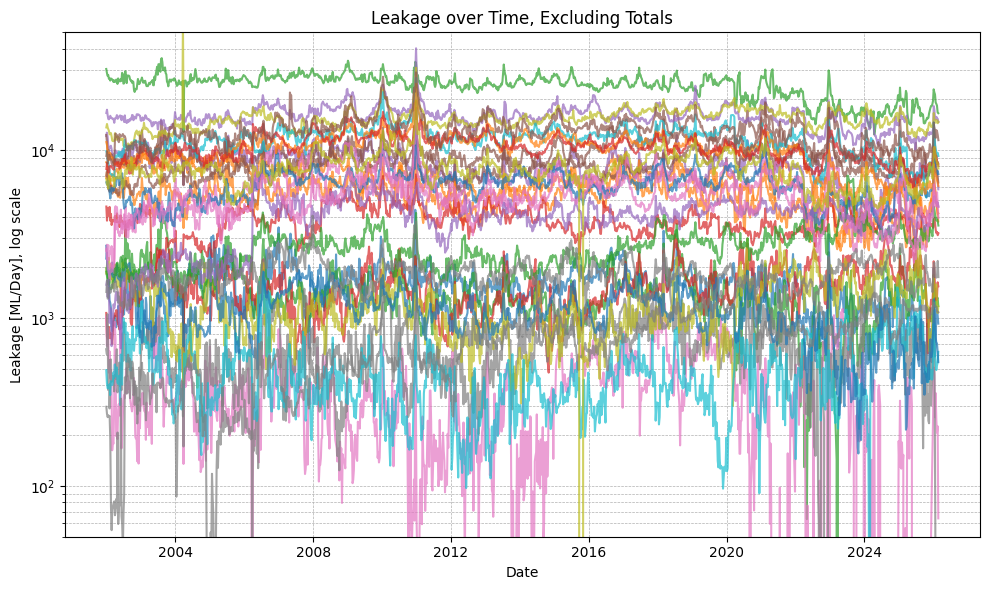

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for d in [dfESW, dfNW]:
    for column in d.columns:
        if column not in ['Total']:
            ax.plot(d.index, d[column], label=column, alpha=0.7)

ax.set_xlabel("Date")
ax.set_ylabel("Leakage [m3/Day], log scale")
ax.set_title("Leakage over Time, Excluding Totals")
#ax.legend(fontsize=10)

ax.set_yscale("log")
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.set_ylim(5e1, 5e4)
plt.tight_layout()

# Missing/Non-Sensical Values

In [28]:
dfESW.isna().sum().sum()

np.int64(0)

In [29]:
dfNW.isna().sum().sum()

np.int64(0)

Excellent!

In [31]:
dfESW[dfESW < 0].count()

m3/day
Zone BA      0
Zone AA      0
Zone AB      1
Zone AF      0
Zone AG      0
Zone AH      0
Zone AK    104
Zone AM     11
Zone AP      0
Zone AS      0
Zone AU      0
Zone AW      0
Zone AZ      0
Total        0
dtype: int64

3 time series have non-sensical values

In [32]:
dfNW[dfNW < 0].count()

m3/day
Zone AC    0
Zone AD    0
Zone AE    0
Zone AI    0
Zone AJ    0
Zone AL    0
Zone AN    0
Zone AO    0
Zone AQ    0
Zone AR    0
Zone AT    0
Zone AV    0
Zone AX    0
Zone AY    0
Zone BB    0
Zone BC    5
Total      0
dtype: int64

# Geographical Locations

In [33]:
from pyproj import Transformer

transformer = Transformer.from_crs("EPSG:27700", "EPSG:4326", always_xy=True)

dfInfo['longitude'], dfInfo['latitude'] = transformer.transform(dfInfo['Easting'], dfInfo['Northing'])

In [44]:
import plotly.express as px

fig = px.scatter_map(dfInfo, lon='longitude', lat='latitude', text='Zone')
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

# Time Period Consistency

In [46]:
NWTimeStamps = dfNW.index
ESWTimeStamps = dfESW.index

In [49]:
NWTimeStamps.diff().value_counts()

7 days    1260
Name: count, dtype: int64

In [50]:
ESWTimeStamps.diff().value_counts()

7 days    1260
Name: count, dtype: int64

Excellent - all observations are perfectly evenly distributed in time (weekly)

# Correlations

"A Vector Autoregression (VAR) model is a statistical framework used to capture the linear interdependencies among multiple time series, where each variable is modeled as a function of its own past values and the past values of all other variables in the system."- Google AI